# Lezione 7A — Agenti LLM e il pattern ReAct

**Corso**: Programmazione di Applicazioni Intelligenti  
**Argomento**: Cos'è un agente, i 3 componenti, il pattern ReAct, implementazione from scratch  
**Durata**: ~1.5 ore (lezione pratica: teoria + live coding)  
**Prerequisiti**: Lezione 06 — Client OpenAI, function calling, MCP

---

**Obiettivi di questa lezione**:
- Capire cosa distingue un **agente** da un semplice LLM con tool
- Conoscere i **3 componenti** fondamentali: Planning, Tools, Memory
- Comprendere il **pattern ReAct** (Reason + Act) e il suo loop
- Implementare un agente ReAct **from scratch** usando solo la libreria `openai`


In [2]:
# === Setup: dipendenze e client Mistral ===
# Eseguire questa cella per prima

!pip install -q openai

from openai import OpenAI
from google.colab import userdata
import json

client = OpenAI(
    base_url="https://api.mistral.ai/v1",
    api_key=userdata.get("MISTRAL_API_KEY"),
)

MODEL = "mistral-small-latest"
print(f"Client configurato — modello: {MODEL}")


Client configurato — modello: mistral-small-latest


---
## 1.1 — Cos'è un agente LLM

Nella lezione 06 abbiamo visto il **function calling**: il modello riceve una domanda, decide di chiamare un tool, riceve il risultato, e produce la risposta finale. Un singolo ciclo: *chiedi → tool → rispondi*.

Un **agente** fa qualcosa in più: può **ripetere** quel ciclo autonomamente, decidendo ad ogni passo cosa fare, quale tool usare, e quando fermarsi.

Ma prima, una distinzione importante. Quando parliamo di "agente", non parliamo di un modello diverso — parliamo di un **layer sopra** il modello:

- **LLM** = il motore (genera token)
- **Reasoning model** = un motore potenziato (genera ragionamento intermedio prima della risposta — es. o3, DeepSeek-R1)
- **Agent harness** = il veicolo che usa il motore (loop di controllo + tool + memoria + gestione contesto)

La metafora è di Sebastian Raschka (*Components of a Coding Agent*, 2026): un agente non è un modello più intelligente — è un **sistema** che usa un modello in modo più efficace, dandogli contesto, tool, e la capacità di iterare. Claude Code, Codex CLI, e simili sono coding harness: lo stesso modello, usato dentro un harness, sembra molto più capace che in una chat semplice.


> Per chi vuole approfondire: il [Mini Coding Agent](https://github.com/rasbt/mini-coding-agent) di Raschka è un agente implementato from scratch in Python puro (~500 righe), con tutti e 6 i componenti annotati nel codice.

**Definizione classica** (Russell & Norvig, *Artificial Intelligence: A Modern Approach*):

> Un agente è un'entità che **percepisce** il proprio ambiente attraverso sensori e **agisce** su di esso attraverso attuatori.

Nel contesto degli LLM, questo si traduce in:
- **Percepisce**: legge il prompt, i risultati dei tool, la cronologia
- **Ragiona**: decide cosa fare dopo (planning)
- **Agisce**: chiama un tool, produce una risposta, scrive in memoria


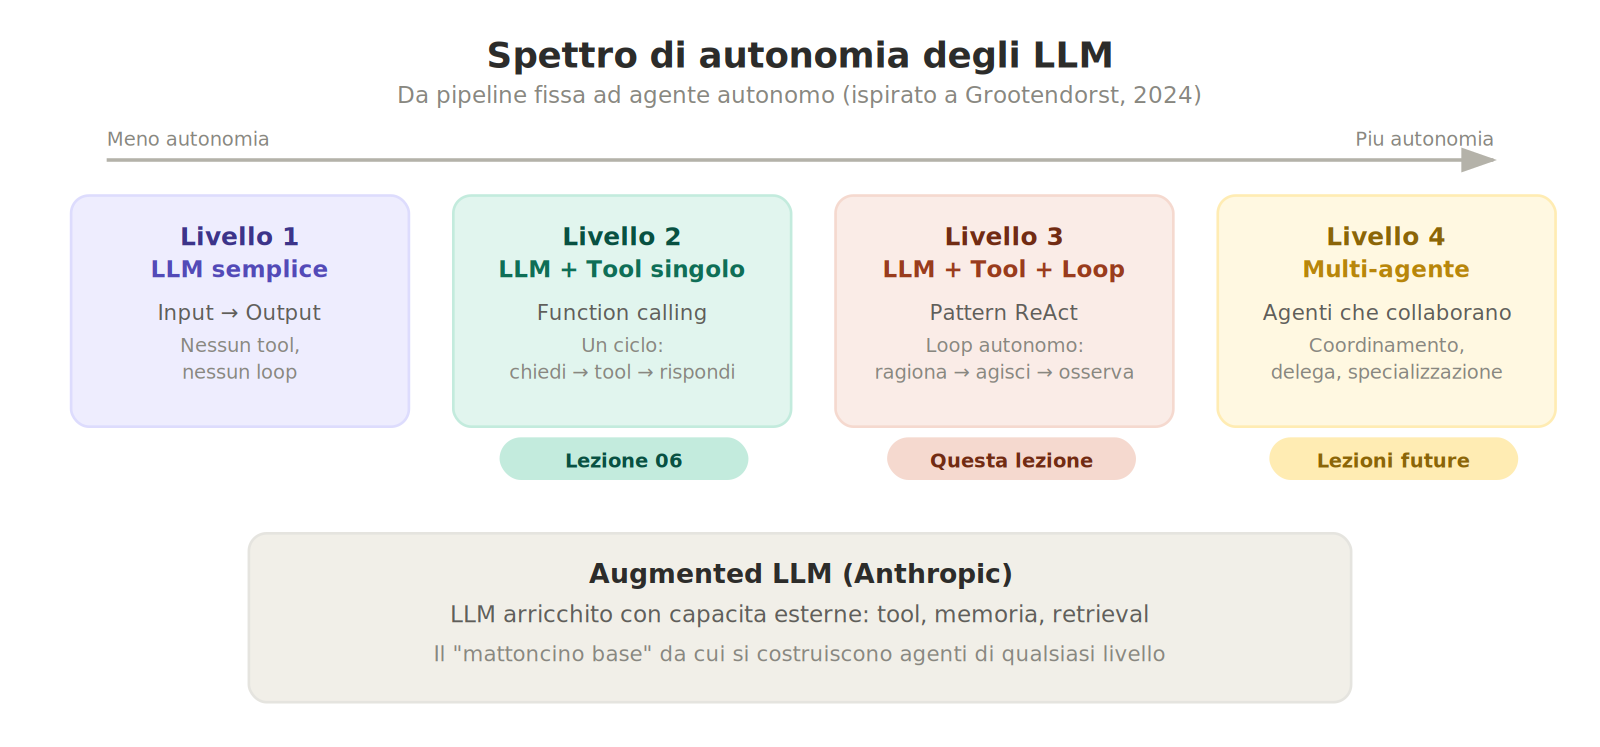

### I pattern agentici: quando serve davvero un agente?

Prima di costruire un agente autonomo, è importante sapere che Anthropic (nel blog "Building Effective Agents") identifica una **scala di pattern** a complessità crescente. Non sempre serve un agente con loop — spesso un pattern più semplice basta:


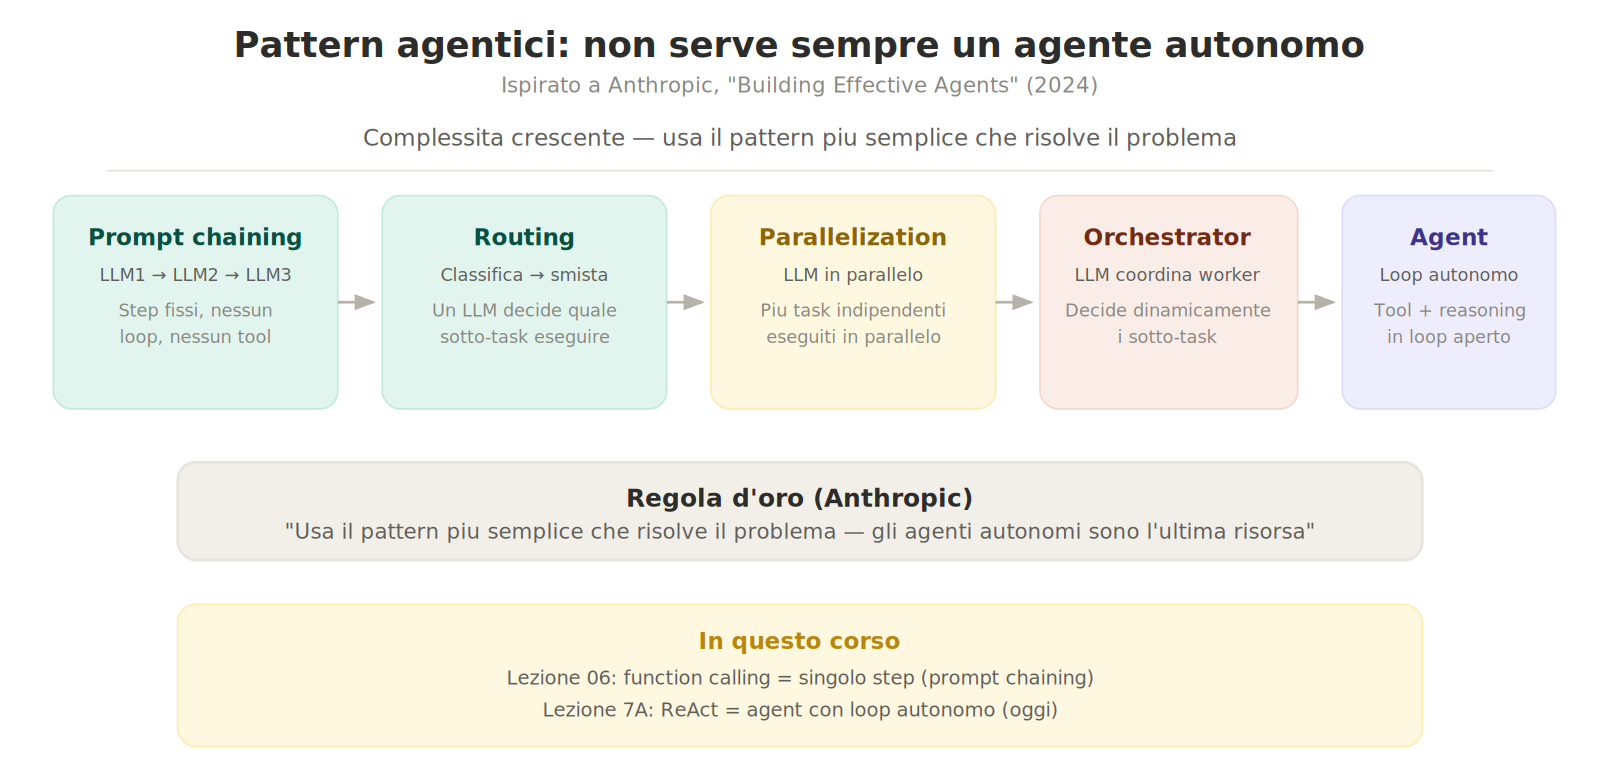

La lezione di oggi si concentra sull'ultimo pattern — l'**agente autonomo con loop** (ReAct). Ma nella pratica, la maggior parte dei problemi si risolve con pattern più semplici. Il function calling della lezione 06 è già un pattern potente (prompt chaining con tool).

> **Nota per il docente**: questo inquadramento è fondamentale — evita che gli studenti pensino che "agente = sempre meglio". Chiedere alla classe: "Per rispondere a 'che tempo fa a Roma?' serve un agente autonomo?". No — basta un singolo function call. L'agente serve quando il numero di step non è prevedibile a priori.


**L'Augmented LLM** (termine usato da Anthropic nel blog "[Building Effective Agents](https://www.anthropic.com/engineering/building-effective-agents)") è il concetto unificante: un LLM arricchito con **tool**, **memoria** e **retrieval** è il mattoncino base. A seconda di quanta autonomia gli diamo nel loop decisionale, otteniamo sistemi di complessità crescente.

> **Nota per il docente**: far notare che la distinzione tra livelli non è netta — è un continuum. Un function calling con retry automatico è già quasi un agente. La differenza chiave è: chi controlla il loop? Se è il codice esterno → pipeline. Se è il modello → agente.


---
## 1.2 — I 3 componenti di un agente

Ogni agente LLM, indipendentemente dal framework usato, si basa su **tre componenti fondamentali**:

1. **Planning** (il cervello) — il modello ragiona su cosa fare, in che ordine, e quando fermarsi
2. **Tools** (le mani) — le funzioni che l'agente può invocare per interagire con il mondo
3. **Memory** (la memoria) — le informazioni che l'agente conserva tra uno step e l'altro


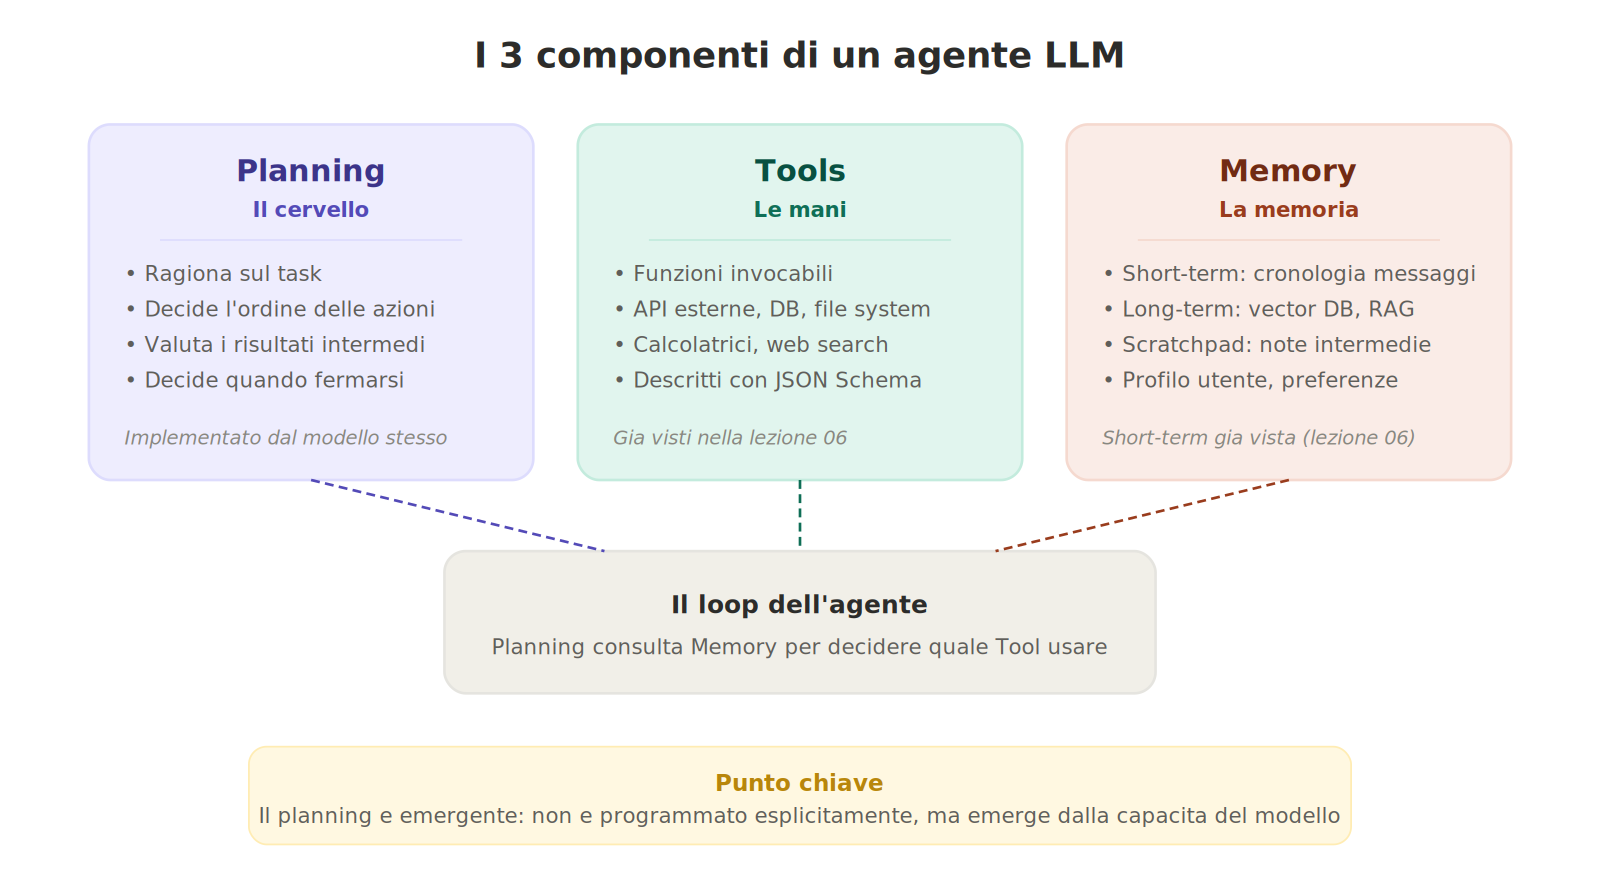

### I 4 tipi di memoria di un agente

La distinzione "short-term / long-term" è utile ma semplificata. Grootendorst & Alammar (*An Illustrated Guide to AI Agents*, O'Reilly 2026) identificano **4 tipi di memoria** ispirati alle architetture cognitive umane:

- **Working memory** (short-term) — la cronologia dei messaggi, alimentata ad ogni turno
- **Episodic memory** — le azioni passate dell'agente e i loro esiti ("ho cercato X e ho trovato Y")
- **Semantic memory** — conoscenza esterna: documenti, DB, codebase (acceduta via RAG o tool)
- **Procedural memory** — pattern appresi: il system prompt, le istruzioni, e i parametri stessi del modello (il modello "sa" scrivere Python perché l'ha imparato nel training)

Un punto fondamentale: l'LLM **non ricorda davvero** le conversazioni passate. Quando sembra ricordare, è perché la cronologia gli viene **esplicitamente reinserita nel prompt** ad ogni chiamata. L'LLM è stateless — tutta la "memoria" è nel contesto che noi gli forniamo. Questo vale anche per ChatGPT e Claude: dietro le quinte, gestiscono la lista `messages` esattamente come abbiamo fatto nella lezione 06.

> **Nota per il docente**: chiedere "Se chiudo il browser e riapro ChatGPT, come fa a ricordare la conversazione?". Risposta: il client (l'app) salva i messaggi in un database e li reinserisce nel prompt. Il modello non ha accesso diretto a quel database — riceve tutto come testo nel contesto.

**Come si collegano i 3 componenti**:
- Il **Planning** è il "motore decisionale" — è il modello stesso che, dato il contesto, genera il prossimo passo
- I **Tools** sono le capacità operative — senza di essi il modello può solo generare testo
- La **Memory** fornisce il contesto — senza di essa ogni step riparte da zero

Il planning non è un modulo separato: è una proprietà **emergente** del modello. Quando scriviamo un buon system prompt e forniamo tool ben descritti, il modello "sa" ragionare su cosa fare. È il pattern ReAct che formalizzeremo nella prossima sezione.

> **Nota per il docente**: chiedere alla classe "Nella lezione 06, quale di questi 3 componenti avevamo?". Risposta: Tools (le funzioni) e Memory short-term (la lista di messaggi). Il Planning c'era in forma embrionale — il modello decideva se chiamare il tool — ma non c'era un loop: il nostro codice faceva un solo ciclo.


---
## 1.3 — Il pattern ReAct: Reason + Act

Il paper **"ReAct: Synergizing Reasoning and Acting in Language Models"** (Yao et al., 2023) ha formalizzato un pattern semplice ma potente:

Ad ogni step, il modello:
1. **Thought** — ragiona sul problema e decide cosa fare
2. **Action** — invoca un tool
3. **Observation** — riceve il risultato del tool

Il ciclo si ripete finché il modello decide di avere abbastanza informazioni per produrre la **risposta finale**.


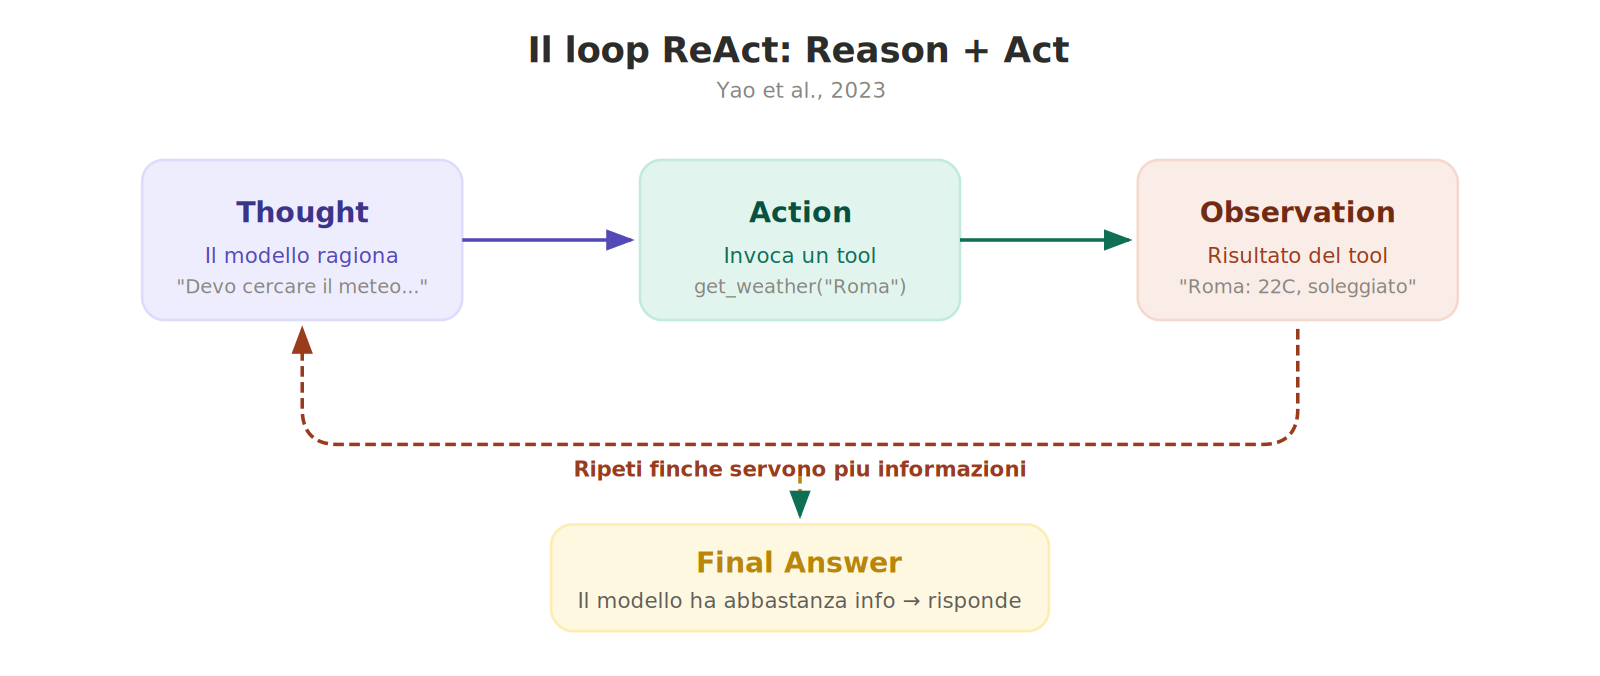

**Confronto con la lezione 06**:

| | Lezione 06 (Function Calling) | Lezione 7 (ReAct) |
|---|---|---|
| **Cicli** | Uno solo | Loop, potenzialmente illimitato |
| **Chi decide?** | Il nostro codice gestisce un singolo round | Il modello decide ad ogni step |
| **Quando si ferma?** | Dopo il primo risultato | Quando il modello lo decide (`finish_reason="stop"`) |
| **Complessità task** | Task semplici, 1 tool call | Task multi-step, tool multipli combinati |

> **Nota per il docente**: il "Thought" nel paper originale era generato esplicitamente come testo. Con le API moderne di function calling, il thought è implicito nel ragionamento del modello — non sempre lo vediamo come testo separato. L'importante è il **loop**: il modello può fare più cicli di tool call prima di rispondere.


---
## 1.4 — ReAct from scratch: implementazione minimale

Implementiamo un agente ReAct **senza framework**, usando solo la libreria `openai` e il function calling via API OpenAI-compatibile (Mistral).

L'idea è semplice — un `while True` che:
1. Chiama il modello con i tool disponibili
2. Se `finish_reason == "tool_calls"` → esegue i tool, aggiunge i risultati, torna al punto 1
3. Se `finish_reason == "stop"` → l'agente ha finito, restituisce la risposta

Il guardrail fondamentale: un parametro `max_steps` per evitare loop infiniti.


In [16]:
# === Definiamo i tool per la demo ===

import random

def get_weather(city: str) -> str:
    """Simula una chiamata API meteo."""
    # In un caso reale, chiameremmo un'API come OpenWeatherMap
    weather_data = {
        "Roma": {"temp": 22, "desc": "soleggiato"},
        "Milano": {"temp": 17, "desc": "pioggia"},
        "Napoli": {"temp": 25, "desc": "soleggiato"},
        "Torino": {"temp": 15, "desc": "pioggia leggera"},
    }
    if city in weather_data:
        w = weather_data[city]
        return f"{city}: {w['temp']}°C, {w['desc']}"
    return f"{city}: dati non disponibili"

def calculate(expression: str) -> str:
    """Calcola un'espressione matematica in modo sicuro."""
    # Usiamo un sottoinsieme sicuro di operazioni
    allowed = set("0123456789+-*/.(). ")
    if not all(c in allowed for c in expression):
        return "Errore: espressione non valida"
    try:
        result = eval(expression)  # Sicuro perche filtriamo i caratteri
        return str(result)
    except Exception as e:
        return f"Errore nel calcolo: {e}"

# Test rapido
print(get_weather("Roma"))
print(calculate("(22 + 17) / 2"))


Roma: 22°C, soleggiato
19.5


In [4]:
# === JSON Schema dei tool (formato OpenAI) ===

tools = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "Ottieni il meteo attuale di una citta italiana. Restituisce temperatura e condizioni.",
            "parameters": {
                "type": "object",
                "properties": {
                    "city": {
                        "type": "string",
                        "description": "Nome della citta (es. 'Roma', 'Milano')"
                    }
                },
                "required": ["city"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "calculate",
            "description": "Calcola un'espressione matematica. Supporta +, -, *, / e parentesi.",
            "parameters": {
                "type": "object",
                "properties": {
                    "expression": {
                        "type": "string",
                        "description": "Espressione matematica da calcolare (es. '(22 + 17) / 2')"
                    }
                },
                "required": ["expression"]
            }
        }
    }
]

# Registry: mappa nome_funzione → funzione Python
tool_registry = {
    "get_weather": get_weather,
    "calculate": calculate,
}

print(f"Tool disponibili: {list(tool_registry.keys())}")


Tool disponibili: ['get_weather', 'calculate']


### Best practice per la definizione dei tool

Tre regole d'oro (Grootendorst & Alammar, 2026) che valgono sia per tool custom che per MCP:

1. **Documenta estensivamente** — il modello sceglie il tool basandosi sulla `description` nel JSON Schema. Una descrizione vaga = scelte sbagliate. Includi cosa fa, cosa restituisce, ed esempi di quando usarlo.

2. **Minimizza il numero di tool** — più tool = più token consumati per le descrizioni + più possibilità che il modello scelga quello sbagliato. Meglio 3-5 tool ben definiti che 20 generici.

3. **Minimizza lo scope di ogni tool** — un tool con 10 parametri opzionali è difficile da usare anche per un umano. Meglio tool piccoli e focalizzati (es. `get_weather(city)` anziché `query_data(source, type, format, filter, ...)`).

> **Nota per il docente**: collegare queste regole al teaser sulle Agent Skills che vedremo nel notebook 7B — il problema del tool overload nasce proprio dalla violazione della regola 2.

### La description fa la differenza: un esperimento dal vivo

Le best practice appena elencate possono sembrare ovvie. Ma quanto cambia *davvero* il comportamento dell'agente se la description di un tool è vaga?

Facciamo un esperimento. Definiamo **3 tool** con nomi opachi (`fetch_alpha`, `fetch_beta`, `transform_gamma`) — come spesso accade con API aziendali reali. Due di essi accettano lo stesso parametro `city`, ma restituiscono dati completamente diversi (uno il meteo, l'altro la popolazione). Confrontiamo cosa succede con description chiare vs vaghe.


In [5]:
# === Esperimento: description buona vs pessima ===
# Nomi opachi: fetch_alpha, fetch_beta, transform_gamma
# fetch_alpha e fetch_beta hanno la STESSA interfaccia (parametro 'city')
# ma uno restituisce il meteo, l'altro la popolazione.
# Con description vaghe il modello non ha modo di distinguerli.

def fetch_alpha_fn(city: str) -> str:
    data = {"roma": "22°C, soleggiato", "milano": "17°C, nuvoloso", "napoli": "25°C, soleggiato"}
    return data.get(city.lower(), "dati non disponibili")

def fetch_beta_fn(city: str) -> str:
    data = {"roma": "2.873.000 abitanti", "milano": "1.396.000 abitanti", "napoli": "920.000 abitanti"}
    return data.get(city.lower(), "dati non disponibili")

def transform_gamma_fn(expression: str) -> str:
    allowed = set("0123456789+-*/.(). ")
    if not all(c in allowed for c in expression):
        return "Errore: espressione non valida"
    try:
        return str(eval(expression))
    except Exception as e:
        return f"Errore: {e}"

tool_fns = {
    "fetch_alpha": fetch_alpha_fn,
    "fetch_beta": fetch_beta_fn,
    "transform_gamma": transform_gamma_fn,
}

# === VERSIONE BUONA: description chiare ===
tools_good = [
    {"type": "function", "function": {
        "name": "fetch_alpha",
        "description": "Restituisce il meteo attuale di una citta italiana: temperatura in °C e condizioni atmosferiche (soleggiato, nuvoloso, pioggia).",
        "parameters": {"type": "object", "properties": {
            "city": {"type": "string", "description": "Nome della citta (es. 'Roma')"}
        }, "required": ["city"]}
    }},
    {"type": "function", "function": {
        "name": "fetch_beta",
        "description": "Restituisce la popolazione residente di una citta italiana (ultimo dato ISTAT disponibile).",
        "parameters": {"type": "object", "properties": {
            "city": {"type": "string", "description": "Nome della citta (es. 'Roma')"}
        }, "required": ["city"]}
    }},
    {"type": "function", "function": {
        "name": "transform_gamma",
        "description": "Calcola un'espressione matematica (+, -, *, /, parentesi). Restituisce il risultato numerico.",
        "parameters": {"type": "object", "properties": {
            "expression": {"type": "string", "description": "Espressione (es. '(22+17)/2')"}
        }, "required": ["expression"]}
    }},
]

# === VERSIONE PESSIMA: description identiche e vaghe ===
tools_bad = [
    {"type": "function", "function": {
        "name": "fetch_alpha",
        "description": "Recupera dati su una citta.",
        "parameters": {"type": "object", "properties": {
            "city": {"type": "string", "description": "Una citta"}
        }, "required": ["city"]}
    }},
    {"type": "function", "function": {
        "name": "fetch_beta",
        "description": "Recupera dati su una citta.",
        "parameters": {"type": "object", "properties": {
            "city": {"type": "string", "description": "Una citta"}
        }, "required": ["city"]}
    }},
    {"type": "function", "function": {
        "name": "transform_gamma",
        "description": "Elabora un dato.",
        "parameters": {"type": "object", "properties": {
            "expression": {"type": "string", "description": "Un dato"}
        }, "required": ["expression"]}
    }},
]

# === Domanda: richiede SOLO meteo + calcolo ===
question = "Che tempo fa a Roma e Milano? Dimmi la media delle temperature."

def run_test(label, tools_schema):
    print(f"\n{'=' * 60}")
    print(f"{label}")
    print(f"{'=' * 60}")
    messages = [
        {"role": "system", "content": "Sei un assistente. Usa i tool per rispondere. Non inventare dati."},
        {"role": "user", "content": question}
    ]
    for step in range(1, 5):
        resp = client.chat.completions.create(model=MODEL, messages=messages, tools=tools_schema)
        choice = resp.choices[0]
        if choice.finish_reason == "stop":
            print(f"  Step {step}: STOP")
            print(f"    → {choice.message.content[:300]}")
            return
        elif choice.finish_reason == "tool_calls":
            messages.append(choice.message)
            for tc in choice.message.tool_calls:
                args = json.loads(tc.function.arguments)
                result = tool_fns[tc.function.name](**args)
                arg_val = list(args.values())[0]
                print(f"  Step {step}: {tc.function.name}('{arg_val}') → {result}")
                messages.append({"role": "tool", "tool_call_id": tc.id, "content": result})
    print("  (max step raggiunto)")

run_test("TEST 1: Description BUONA", tools_good)
run_test("TEST 2: Description PESSIMA (volutamente ambigua)", tools_bad)



TEST 1: Description BUONA
  Step 1: fetch_alpha('Roma') → 22°C, soleggiato
  Step 1: fetch_alpha('Milano') → 17°C, nuvoloso
  Step 2: transform_gamma('(22+17)/2') → 19.5
  Step 3: STOP
    → A Roma il tempo è **22°C e soleggiato**, mentre a Milano è **17°C e nuvoloso**.

La **media delle temperature** tra le due città è **19,5°C**.

TEST 2: Description PESSIMA (volutamente ambigua)
  Step 1: fetch_alpha('Roma') → 22°C, soleggiato
  Step 1: fetch_beta('Milano') → 1.396.000 abitanti
  Step 2: transform_gamma('(22 + 15) / 2') → 18.5
  Step 3: STOP
    → A Roma il tempo è **22°C e soleggiato**.
A Milano non ho ricevuto dati meteorologici, ma so che ha **1.396.000 abitanti**.

Non posso calcolare la media delle temperature senza il dato di Milano. Vuoi che riprova a cercare informazioni per Milano?


**Cosa osservare**:

- `fetch_alpha` e `fetch_beta` hanno **nome opaco**, **stesso parametro** (`city`), **stesso tipo** — sono indistinguibili senza la description.
- Con la description buona, il modello sa che `fetch_alpha` = meteo e `fetch_beta` = popolazione. Chiama solo `fetch_alpha` + `transform_gamma`.
- Con la description pessima (entrambi: "Recupera dati su una citta"), il modello **deve tirare a indovinare**. Comportamenti tipici:
  - Chiama `fetch_beta` invece di `fetch_alpha` → riceve la popolazione, non la temperatura
  - Chiama entrambi "per sicurezza" → spreco di token, e poi non sa quale risultato usare
  - Chiama quello giusto per caso (50/50!) ma non in modo riproducibile
- Questo scenario è realistico: nelle API aziendali i nomi sono spesso criptici (`fetch_v2`, `get_data_prod`). **La description è l'unica documentazione che il modello legge.**

> **Take-away**: la description è l'equivalente della documentazione di un'API — senza di essa, nemmeno un modello forte sceglie lo strumento giusto. In Agno, la description viene generata dalla **docstring** della funzione Python: un motivo in più per scrivere buone docstring.


### Un dettaglio cruciale: chi esegue il tool?

Quando il modello "chiama un tool", in realtà **non esegue nulla**. Genera una stringa strutturata (il JSON con nome e argomenti del tool) — è la sua **intenzione** di chiamare un tool, non l'esecuzione.

L'esecuzione vera avviene nel nostro codice: noi leggiamo il JSON, chiamiamo la funzione Python, e **reinseriamo il risultato nei messaggi** come se il modello l'avesse ottenuto. Il modello non sa cosa è successo "fuori" — lo informiamo noi con un messaggio `role: "tool"`.

Questo è lo stesso meccanismo della lezione 06, ma nel loop ReAct si ripete potenzialmente più volte. Ogni iterazione del loop è un ciclo: il modello esprime un'intenzione → noi la eseguiamo → gli riportiamo il risultato.

### Il cuore dell'agente: il loop ReAct

La funzione `react_agent` implementa il ciclo completo. Osserva come il loop è controllato dal modello, non da noi:


In [7]:
# === L'agente ReAct from scratch ===

def react_agent(question: str, tools: list, tool_registry: dict, max_steps: int = 10) -> str:
    """
    Agente ReAct minimale.
    - question: la domanda dell'utente
    - tools: lista di tool schema (formato OpenAI)
    - tool_registry: dict nome → funzione Python
    - max_steps: massimo numero di cicli per evitare loop infiniti
    """
    messages = [
        {
            "role": "system",
            "content": (
                "Sei un assistente utile. Usa i tool a disposizione per rispondere "
                "alle domande. Puoi fare piu chiamate a tool in sequenza se necessario. "
                "Quando hai tutte le informazioni, rispondi in modo chiaro e completo."
            )
        },
        {"role": "user", "content": question}
    ]

    for step in range(1, max_steps + 1):
        print(f"\n{'='*60}")
        print(f"STEP {step}")
        print(f"{'='*60}")

        # 1. Chiama il modello
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools,
        )

        choice = response.choices[0]
        message = choice.message

        # 2. Controlla finish_reason
        if choice.finish_reason == "stop":
            # L'agente ha deciso di fermarsi e rispondere
            print(f"[FINAL ANSWER]")
            print(message.content)
            return message.content

        elif choice.finish_reason == "tool_calls":
            # L'agente vuole chiamare uno o piu tool
            print(f"[TOOL CALLS] Il modello richiede {len(message.tool_calls)} tool call(s)")

            # Aggiungi il messaggio dell'assistente (con le tool_calls) alla cronologia
            messages.append(message)

            # 3. Esegui ogni tool call
            for tc in message.tool_calls:
                func_name = tc.function.name
                func_args = json.loads(tc.function.arguments)

                print(f"  → Chiamo {func_name}({func_args})")

                # Esegui la funzione
                if func_name in tool_registry:
                    result = tool_registry[func_name](**func_args)
                else:
                    result = f"Errore: tool '{func_name}' non trovato"

                print(f"  ← Risultato: {result}")

                # Aggiungi il risultato alla cronologia
                messages.append({
                    "role": "tool",
                    "tool_call_id": tc.id,
                    "content": str(result)
                })
        else:
            # finish_reason inatteso
            print(f"[UNEXPECTED] finish_reason={choice.finish_reason}")
            return message.content or "Errore: risposta inattesa dal modello"

    # Se arriviamo qui, abbiamo esaurito max_steps
    print(f"\n[TIMEOUT] Raggiunto il limite di {max_steps} step")
    return "Mi dispiace, non sono riuscito a completare il task nel numero massimo di step."


### Demo: task multi-step

Proviamo con una domanda che richiede **più tool call** in sequenza:

> *"Che tempo fa a Roma e Milano? Qual è la media delle temperature?"*

L'agente dovrebbe:
1. Chiamare `get_weather("Roma")` e `get_weather("Milano")` (possibilmente in parallelo)
2. Chiamare `calculate()` per fare la media
3. Sintetizzare la risposta finale


In [9]:
# === Demo: task multi-step ===

risposta = react_agent(
    question="Dove fa più caldo tra Roma, Milano, Napoli e Torino?",
    tools=tools,
    tool_registry=tool_registry,
    max_steps=10
)

print("\n" + "="*60)
print("RISPOSTA FINALE:")
print("="*60)
print(risposta)



STEP 1
[TOOL CALLS] Il modello richiede 4 tool call(s)
  → Chiamo get_weather({'city': 'Roma'})
  ← Risultato: Roma: 22°C, soleggiato
  → Chiamo get_weather({'city': 'Milano'})
  ← Risultato: Milano: 17°C, nuvoloso
  → Chiamo get_weather({'city': 'Napoli'})
  ← Risultato: Napoli: 25°C, soleggiato
  → Chiamo get_weather({'city': 'Torino'})
  ← Risultato: Torino: 15°C, pioggia leggera

STEP 2
[FINAL ANSWER]
Tra le città richieste, **Napoli** è quella dove fa più caldo con **25°C** e condizioni soleggiate. Ecco un riassunto delle temperature:

- **Napoli**: 25°C, soleggiato
- **Roma**: 22°C, soleggiato
- **Milano**: 17°C, nuvoloso
- **Torino**: 15°C, pioggia leggera

RISPOSTA FINALE:
Tra le città richieste, **Napoli** è quella dove fa più caldo con **25°C** e condizioni soleggiate. Ecco un riassunto delle temperature:

- **Napoli**: 25°C, soleggiato
- **Roma**: 22°C, soleggiato
- **Milano**: 17°C, nuvoloso
- **Torino**: 15°C, pioggia leggera


### Anatomia dell'esecuzione

Il diagramma mostra cosa succede "sotto il cofano":


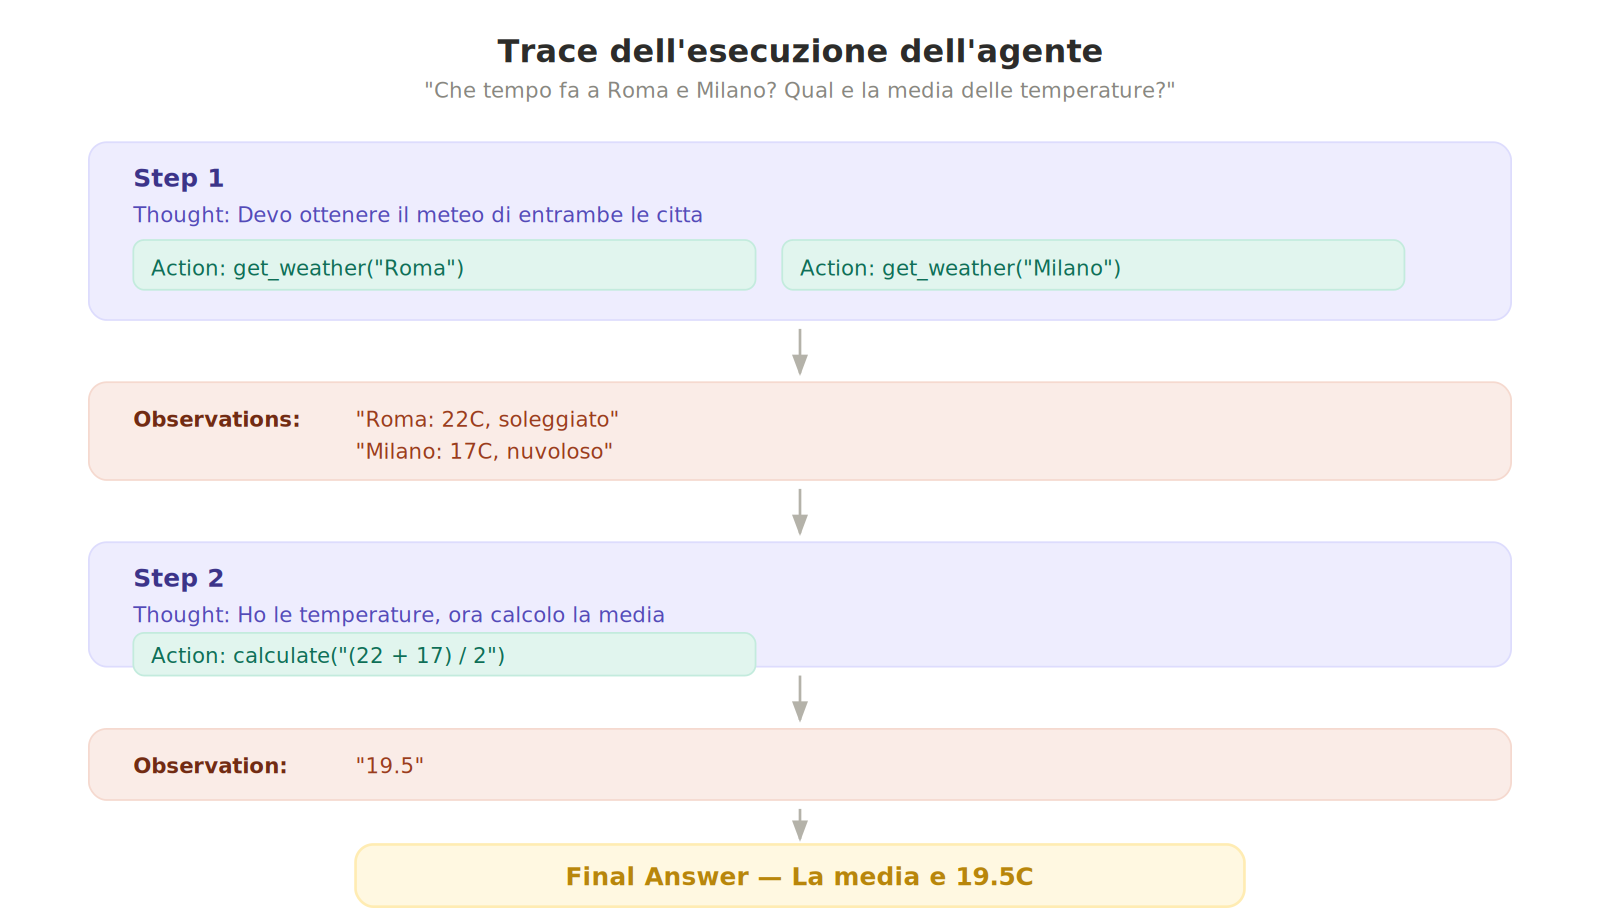

> **Nota per il docente**: far osservare che nello Step 1, il modello potrebbe chiamare entrambi i tool nella stessa risposta (parallel tool calls) oppure uno per volta — dipende dal modello. Il nostro codice gestisce entrambi i casi perché itera su `message.tool_calls`. Questo è un vantaggio dell'approccio OpenAI rispetto all'output testuale del paper ReAct originale.


---
## 1.5 — Limiti e rischi degli agenti autonomi

Gli agenti sono potenti ma introducono nuove classi di rischio:

| Rischio | Descrizione | Mitigazione |
|---|---|---|
| **Loop infiniti** | Il modello non converge, continua a chiamare tool | `max_steps` (l'abbiamo gia implementato) |
| **Allucinazioni amplificate** | Se un tool restituisce dati sbagliati, l'agente li propaga e ci ragiona sopra | Validazione degli output dei tool |
| **Costi imprevedibili** | Ogni step consuma token; il costo totale dipende dal numero di step | Budget di token, `max_steps` |
| **Sicurezza** | Un agente con tool potenti (email, DB, file system) puo fare danni | **Human-in-the-loop** per azioni critiche |
| **Osservabilita** | Difficile capire *perche* l'agente ha fatto una scelta | Logging strutturato di ogni step |

**Best practice**:
- Loggare **ogni step**: tool chiamato, argomenti, risultato, token usati
- **Human-in-the-loop**: chiedere conferma per azioni irreversibili (invio email, modifica DB)
- **Sandbox**: eseguire i tool in un ambiente isolato quando possibile
- **Principio del minimo privilegio**: dare all'agente solo i tool strettamente necessari


In [25]:
# === Esempio: agente con logging migliorato ===
# Questa versione aggiunge il conteggio dei token

def react_agent_with_logging(question: str, tools: list, tool_registry: dict, max_steps: int = 10) -> dict:
    """
    Agente ReAct con logging strutturato.
    Restituisce un dict con la risposta e le metriche.
    """
    messages = [
        {
            "role": "system",
            "content": (
                "Sei un assistente utile. Usa i tool a disposizione per rispondere. "
                "Puoi fare piu chiamate a tool in sequenza se necessario."

            )
        },
        {"role": "user", "content": question}
    ]

    log = []
    total_tokens = 0

    for step in range(1, max_steps + 1):
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools,
        )

        choice = response.choices[0]
        message = choice.message

        # Conta i token di questo step
        usage = response.usage
        step_tokens = usage.total_tokens if usage else 0
        total_tokens += step_tokens

        step_log = {
            "step": step,
            "finish_reason": choice.finish_reason,
            "tokens_this_step": step_tokens,
            "tool_calls": []
        }

        if choice.finish_reason == "stop":
            step_log["final_answer"] = message.content
            log.append(step_log)
            return {
                "answer": message.content,
                "steps": len(log),
                "total_tokens": total_tokens,
                "log": log
            }

        elif choice.finish_reason == "tool_calls":
            messages.append(message)

            for tc in message.tool_calls:
                func_name = tc.function.name
                func_args = json.loads(tc.function.arguments)

                if func_name in tool_registry:
                    result = tool_registry[func_name](**func_args)
                else:
                    result = f"Errore: tool '{func_name}' non trovato"

                step_log["tool_calls"].append({
                    "tool": func_name,
                    "args": func_args,
                    "result": result
                })

                messages.append({
                    "role": "tool",
                    "tool_call_id": tc.id,
                    "content": str(result)
                })

        log.append(step_log)

    return {
        "answer": "Timeout: troppi step",
        "steps": max_steps,
        "total_tokens": total_tokens,
        "log": log
    }


In [11]:
# === Eseguiamo l'agente con logging ===

result = react_agent_with_logging(
    question="Che tempo fa a Roma, Milano e Napoli? Qual e' la citta piu calda?",
    tools=tools,
    tool_registry=tool_registry
)

print(f"Risposta: {result['answer']}")
print(f"\nStep totali: {result['steps']}")
print(f"Token totali: {result['total_tokens']}")
print(f"\n--- Log dettagliato ---")
for entry in result['log']:
    print(f"\nStep {entry['step']} (finish_reason={entry['finish_reason']}, tokens={entry['tokens_this_step']})")
    for tc in entry['tool_calls']:
        print(f"  {tc['tool']}({tc['args']}) → {tc['result']}")
    if 'final_answer' in entry:
        print(f"  [RISPOSTA FINALE]")


Risposta: Ecco il meteo attuale per le città richieste:

- **Roma**: 22°C, soleggiato
- **Milano**: 17°C, nuvoloso
- **Napoli**: 25°C, soleggiato

La città più calda è **Napoli** con **25°C**.

Step totali: 2
Token totali: 697

--- Log dettagliato ---

Step 1 (finish_reason=tool_calls, tokens=294)
  get_weather({'city': 'Roma'}) → Roma: 22°C, soleggiato
  get_weather({'city': 'Milano'}) → Milano: 17°C, nuvoloso
  get_weather({'city': 'Napoli'}) → Napoli: 25°C, soleggiato

Step 2 (finish_reason=stop, tokens=403)
  [RISPOSTA FINALE]


---
## 1.6 — Quando l'agente fallisce: debug dal vivo

La tabella dei rischi della sezione precedente è utile, ma astratta. Vediamo **dal vivo** cosa succede quando diamo al nostro `react_agent` dei prompt "difficili".

Usiamo l'agente con logging che abbiamo appena costruito — così possiamo osservare la trace completa.


In [12]:
# === Failure mode 1: il modello "sa gia'" e non usa i tool ===
# Domanda su un fatto noto — il modello potrebbe rispondere senza tool

print("=" * 60)
print("FAILURE MODE 1: bypass dei tool (allucinazione plausibile)")
print("=" * 60)

result1 = react_agent_with_logging(
    question="Qual e' la capitale della Francia?",
    tools=tools,
    tool_registry=tool_registry
)

print(f"\nRisposta: {result1['answer']}")
print(f"Step: {result1['steps']}, Tool calls: {sum(len(e.get('tool_calls',[])) for e in result1['log'])}")
print("\n→ Il modello risponde correttamente... ma NON ha usato nessun tool.")
print("  In un caso reale con dati aggiornati (es. meteo, prezzi), questo")
print("  significherebbe che l'agente inventa la risposta invece di cercarla.")


FAILURE MODE 1: bypass dei tool (allucinazione plausibile)

Risposta: La capitale della Francia è **Parigi**.
Step: 1, Tool calls: 0

→ Il modello risponde correttamente... ma NON ha usato nessun tool.
  In un caso reale con dati aggiornati (es. meteo, prezzi), questo
  significherebbe che l'agente inventa la risposta invece di cercarla.


In [13]:
# === Failure mode 2: tool non disponibile ===
# Domanda che richiederebbe un tool che non abbiamo

print("=" * 60)
print("FAILURE MODE 2: tool mancante")
print("=" * 60)

result2 = react_agent_with_logging(
    question="Cerca su Wikipedia chi ha inventato il telefono e calcola quanti anni fa.",
    tools=tools,  # abbiamo solo get_weather e calculate, NON search_wikipedia
    tool_registry=tool_registry
)

print(f"\nRisposta: {result2['answer']}")
print(f"Step: {result2['steps']}")
print("\n→ Il modello non ha 'search_wikipedia', quindi o:")
print("  a) Inventa la risposta dalla sua conoscenza (allucinazione mascherata)")
print("  b) Prova a chiamare un tool che non esiste (errore nel registry)")
print("  c) Dice onestamente che non puo fare la ricerca")
print("  Quale dei tre? Dipende dal modello e dal system prompt.")


FAILURE MODE 2: tool mancante

Risposta: Mi dispiace, ma non ho accesso a strumenti per cercare su Wikipedia direttamente. Tuttavia, posso dirti che **Alexander Graham Bell** è generalmente riconosciuto come l'inventore del telefono, anche se ci sono dibattiti su altri inventori come **Elisha Gray** e **Antonio Meucci**.

Se vuoi, posso calcolare quanti anni fa è nato Alexander Graham Bell (1847) rispetto all'anno corrente (2024). Fammi sapere!
Step: 1

→ Il modello non ha 'search_wikipedia', quindi o:
  a) Inventa la risposta dalla sua conoscenza (allucinazione mascherata)
  b) Prova a chiamare un tool che non esiste (errore nel registry)
  c) Dice onestamente che non puo fare la ricerca
  Quale dei tre? Dipende dal modello e dal system prompt.


In [21]:
# === Failure mode 3: domanda ambigua che puo' causare loop ===

print("=" * 60)
print("FAILURE MODE 3: ambiguita' e possibile loop")
print("=" * 60)

# Domanda volutamente ambigua che potrebbe mandare in loop
result3 = react_agent_with_logging(
    question="Controlla il meteo in tutte le citta che conosci e dimmi dove piove. E a Milano?",
    tools=tools,
    tool_registry=tool_registry,
    max_steps=5  # Limitiamo a 5 per non aspettare troppo
)

print(f"\nRisposta: {result3['answer'][:300]}")
print(f"Step: {result3['steps']}, Token totali: {result3['total_tokens']}")
print("\n→ 'Tutte le citta italiane' e' vago: il modello non sa quante provare.")
print("  Potrebbe chiamare get_weather per decine di citta fino al max_steps.")
print("  Soluzione: istruzioni piu precise, oppure un tool 'list_available_cities'.")


FAILURE MODE 3: ambiguita' e possibile loop

Risposta: Ecco le informazioni sul meteo per le città che sono riuscito a controllare:

- **Roma**: 22°C, soleggiato
- **Milano**: 17°C, nuvoloso
- **Napoli**: 25°C, soleggiato
- **Torino**: 15°C, **pioggia leggera**
- **Palermo**: Dati non disponibili
- **Genova**: Dati non disponibili
- **Bologna**: Dati no
Step: 2, Token totali: 1048

→ 'Tutte le citta italiane' e' vago: il modello non sa quante provare.
  Potrebbe chiamare get_weather per decine di citta fino al max_steps.
  Soluzione: istruzioni piu precise, oppure un tool 'list_available_cities'.


In [26]:
print("=" * 60)
print("TEST 4: domane out of scope")
print("=" * 60)

# Domanda volutamente ambigua che potrebbe mandare in loop
result4 = react_agent_with_logging(
    question="Chi vincerà il campionato di calcio quest'anno?",
    tools=tools,
    tool_registry=tool_registry,
    max_steps=5  # Limitiamo a 5 per non aspettare troppo
)

print(f"\nRisposta: {result4['answer']}")

TEST 4: domane out of scope

Risposta: Non posso prevedere il futuro, quindi non so chi vincerà il campionato di calcio quest'anno. Tuttavia, posso aiutarti con altre informazioni o calcoli se ne hai bisogno!


**Lezioni dai fallimenti**:

| Failure mode | Causa | Soluzione |
|---|---|---|
| Tool bypass | Il modello "sa già" la risposta | Aggiungere nel system prompt: *"Usa SEMPRE i tool per ottenere dati. Non rispondere mai dalla tua conoscenza."* |
| Tool mancante | L'utente chiede qualcosa fuori scope | Aggiungere un tool "fallback" o istruire l'agente a dire "non ho il tool necessario" |
| Loop da ambiguità | La domanda è troppo aperta | Limitare `max_steps`, oppure aggiungere un tool che elenca le opzioni disponibili |

Questi pattern di fallimento li ritroveremo nella Lezione 10, dove costruiremo un agente più robusto. Il primo passo per un agente affidabile è **sapere come fallisce**.

> **Nota per il docente**: questi 3 scenari sono pensati per essere eseguiti live in aula. Il risultato è non deterministico — ogni esecuzione può dare un comportamento diverso, il che è un ottimo spunto di discussione ("il vostro ha fatto lo stesso?"). Se il tempo è poco, il failure mode 1 è il più rapido e impattante.


---
## Riepilogo

In questa prima parte della lezione abbiamo:

1. **Definito cos'è un agente** — un LLM che opera in un loop autonomo, non un singolo ciclo di function calling
2. **Identificato i 3 componenti** — Planning (il modello ragiona), Tools (le funzioni), Memory (il contesto)
3. **Formalizzato il pattern ReAct** — Thought → Action → Observation, in loop fino alla risposta finale
4. **Implementato un agente ReAct from scratch** — ~50 righe di Python con la libreria `openai`, senza framework
5. **Visto dal vivo i fallimenti** — tool bypass, tool mancanti, loop da ambiguità
6. **Discusso limiti e rischi** — loop infiniti, allucinazioni amplificate, costi, sicurezza

**Nella prossima parte** (Notebook 7B): Skills, Context Engineering, e introduzione ad Agno per semplificare tutto questo.

> **Nota per il docente**: prima di passare al notebook successivo, chiedere se ci sono domande. Un buon esercizio alla lavagna: far disegnare a uno studente la trace di un task a 4 step, identificando Thought/Action/Observation di ogni step.
